In [8]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

In [9]:
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

MAX_TOKENS = 150

In [10]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> Last N messages that fit within the toke budget
    messages = trim_messages(
        state['messages'],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )
    
    print("Current Token Count ->", count_tokens_approximately(messages=messages))
    
    for message in messages:
        print(message.content)
    
    response = model.invoke(messages)
    
    return {"messages": [response]}

In [11]:
builder = StateGraph(MessagesState)

builder.add_node("call_model", call_model)

builder.add_edge(START, "call_model")

In [12]:
checkpointer = InMemorySaver()

graph = builder.compile(checkpointer=checkpointer)

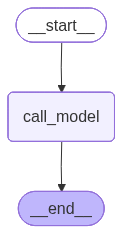

In [13]:
graph

In [14]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hey, My name is Yash"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 9
Hey, My name is Yash


[{'type': 'text',
  'text': "Hi Yash! It's nice to meet you. How are you doing today? Is there anything I can help you with?",
  'extras': {'signature': 'EjQKMgERTTIPQf0BxGCRB8R0YnjdM009p3ZL9SOlyXTgxiFEV2o01rTQnGQJ4LEa8/Z9NOO2'}}]

In [15]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 48
Hey, My name is Yash
[{'type': 'text', 'text': "Hi Yash! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgERTTIPQf0BxGCRB8R0YnjdM009p3ZL9SOlyXTgxiFEV2o01rTQnGQJ4LEa8/Z9NOO2'}}]
I am learning LangGraph.


[{'type': 'text',
  'text': 'That’s fantastic! **LangGraph** is currently one of the most powerful tools for building agentic workflows and stateful applications. It really bridges the gap between simple LLM chains and truly autonomous agents.\n\nSince you\'re just starting, how would you describe your current progress? \n\n*   **Are you a complete beginner** and want an overview of the core concepts (like the `StateGraph` and `nodes`)?\n*   **Are you looking to build something specific** (like a chatbot with memory, a research agent, or a RAG workflow)?\n*   **Or are you stuck on a specific error/concept** (like how `State` updates or `checkpoints` work)?\n\nIf you\'re just diving in, here are the three "pillars" I usually recommend focusing on first:\n\n1.  **The State:** Understanding that everything in LangGraph revolves around a shared object that you pass between functions.\n2.  **Nodes & Edges:** How to think of your workflow as a graph where nodes are functions and edges are th

In [16]:

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


[{'type': 'text',
  'text': 'Short-term memory (STM), often referred to as **"working memory,"** is the brain\'s system for holding a small amount of information in an active, readily available state for a brief period of time.\n\nThink of it as the **RAM (Random Access Memory) of your brain**: it is the workspace where you process information before deciding whether to discard it or move it into long-term storage.\n\nHere is a breakdown of how it works:\n\n---\n\n### 1. The Key Characteristics\n*   **Limited Capacity:** You can only hold a few items at once. Historically, psychologists suggested the "Magic Number 7 (plus or minus 2)," meaning most people can hold between 5 and 9 items. Modern research suggests it is actually closer to **4 items**.\n*   **Short Duration:** Information in short-term memory lasts only about **15 to 30 seconds** unless you actively practice it (like repeating a phone number over and over).\n*   **Fragility:** It is highly susceptible to interference. If y

In [17]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


[{'type': 'text',
  'text': 'I do not know your name. As an AI, I don’t have access to your personal information, private documents, or webcam unless you have explicitly provided that information in our current conversation.',
  'extras': {'signature': 'EjQKMgERTTIPqHzEhYinQZWG06qLNthvEU8ozTkypEU7T9SB5ZDf5cJKB8nfN5Of2W1DgIsm'}}]

In [18]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hey, My name is Yash
------------------------------------------------------------------------------------------------------------------------
[{'type': 'text', 'text': "Hi Yash! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgERTTIPQf0BxGCRB8R0YnjdM009p3ZL9SOlyXTgxiFEV2o01rTQnGQJ4LEa8/Z9NOO2'}}]
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
[{'type': 'text', 'text': 'That’s fantastic! **LangGraph** is currently one of the most powerful tools for building agentic workflows and stateful applications. It really bridges the gap between simple LLM chains and truly autonomous agents.\n\nSince you\'re just starting, how would you describe your current progress? \n\n*   **Are you a complete beginner** and 